# Quantile Transformer

Этот метод трансформации признаков преобразует распределение переменной в нормальное или равномерное распределение и масштабирует его соответствующим образом.

__Квантильное преобразование__ сопоставляет распределение вероятностей переменной с другим распределением вероятностей с использованием квантильной функции.

__Квантильная функция__, также называемая __функцией процентной точки (PPF)__, является обратной функцией кумулятивного распределения вероятностей (CDF).

__CDF__ — это функция, которая возвращает вероятность значения, равного или меньше заданного значения.

__PPF__ является инверсией этой функции и возвращает значение с заданной вероятностью или ниже неё.

<img src='Images/ml_05.png'>

Это квантильное преобразование доступно в библиотеке машинного обучения Python scikit-learn через класс QuantileTransformer.

У класса есть аргумент output_distribution, который отвечает за тип выходного распределения. Он может принимать значение 'uniform' (равномерное распределение) или 'normal' (нормальное распределение). По умолчанию используется равномерное распределение, то есть значение параметра равно 'uniform'.

Гиперпараметр n_quantiles определяет разрешение отображения или ранжирование наблюдений в наборе данных. Это значение должно быть меньше, чем количество наблюдений в наборе данных, и по умолчанию равно 1000.

### Важно:

Поскольку этот метод изменяет само распределение переменных, из-за этого скейлера линейные отношения между переменными могут быть разрушены. Таким образом, лучше всего использовать его для __нелинейных данных__.

__Нелинейные данные__ — это данные, в которых зависимость между признаками и целевой переменной не описывается прямой линией.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer

# Загрузка данных

In [5]:
# %%capture
# !wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [6]:
ford_price_data = pd.read_excel('Data/data_ford_price.xlsx')

# Трансформация признаков

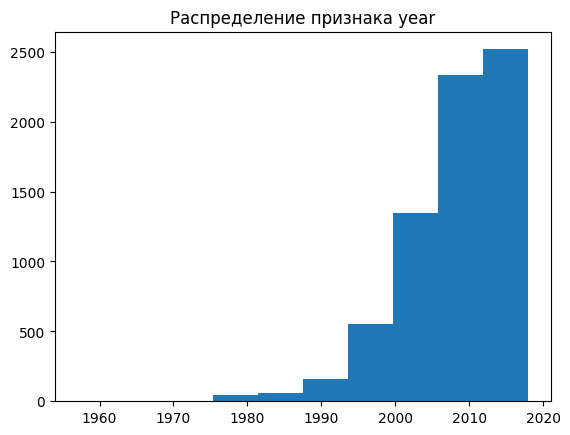

In [7]:
plt.hist(ford_price_data.year)
plt.title('Распределение признака year');

## Квантильное преобразование

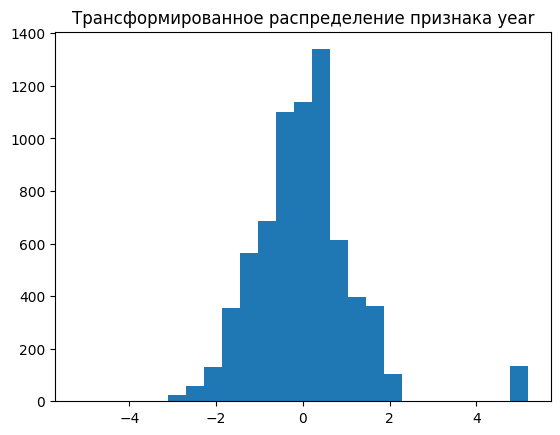

In [8]:
# Данный трансформер принимает на вход 2D-массив,
# поэтому нам надо изменить формат данных (поскольку мы подаём на вход только один столбец)
data_for_transform = ford_price_data['year'].values.reshape((len(ford_price_data), 1))

quantile = QuantileTransformer(output_distribution='normal') # на выходе нормальное распределение
data_transformed = quantile.fit_transform(data_for_transform)
 
plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака year')
plt.show()

Далее преобразуем распределения признаков condition и cylinders в равномерное. Далее выведим значение признака condition у нулевого объекта и округлим до второго знака после точки.

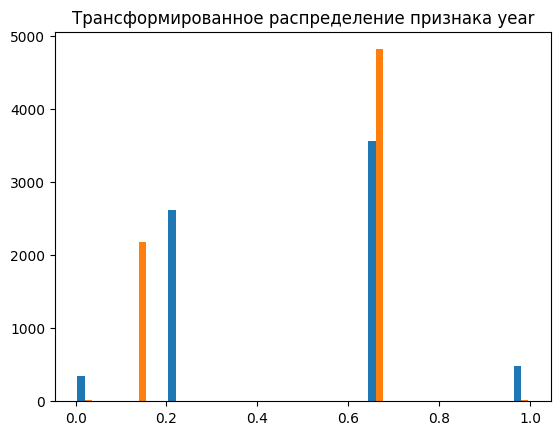

In [15]:
data_for_transform = ford_price_data[['condition', 'cylinders']].to_numpy()

quantile = QuantileTransformer(output_distribution='uniform') # на выходе равномерное распределение
data_transformed = quantile.fit_transform(data_for_transform)
 
plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака year')
plt.show()

In [17]:
display(round(data_transformed[0, 0], 2))

0.96

# Логарифмическое преобразование (Log Transform)

__Логарифмическое преобразование__ — один из самых популярных методов преобразования. В основном оно используется для превращения асимметричного распределения в нормальное/менее асимметричное. В этом преобразовании мы берём логарифм значений признака вместо самих значений.

Почему это работает? Потому что функция логарифма создана для работы с большими числами.

Посмотрим на распределение признака price. Оно асимметрично, причём значения варьируются от 0 до ~300_000.

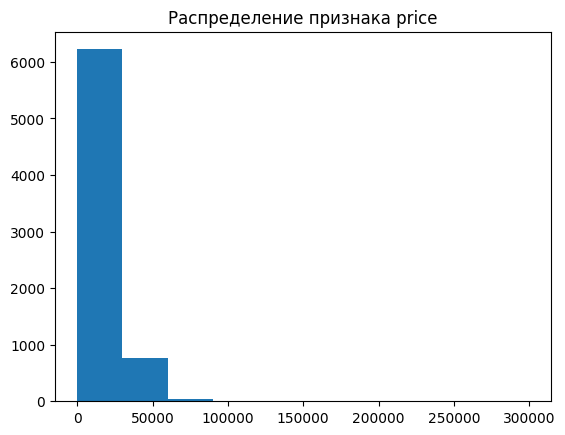

In [22]:
plt.hist(ford_price_data.price)
plt.title('Распределение признака price');

Идеальный кандидат для логарифмического преобразования — применим его. На этот раз обойдёмся силами numpy.

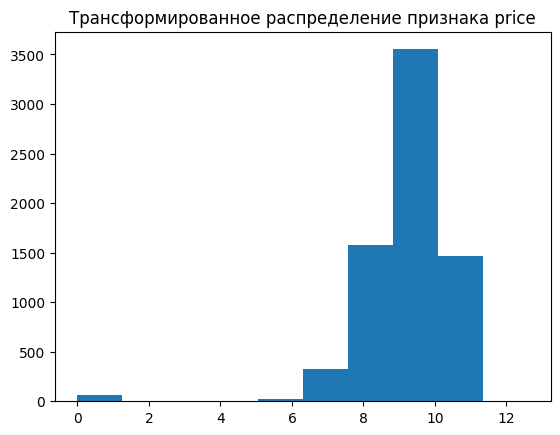

In [23]:
log_price = np.log(ford_price_data['price'])
 
plt.hist(log_price)
plt.title('Трансформированное распределение признака price')
plt.show()

In [24]:
price_data = pd.concat([ford_price_data['price'], log_price.rename('transformed_price')], axis = 1)

price_data.describe()

,price,transformed_price
count,7017.000000,7017.000000
mean,15121.549523,9.204510
std,11765.423119,1.275868
min,1.000000,0.000000
25%,5995.000000,8.698681
50%,12750.000000,9.453287
75%,21995.000000,9.998570
max,299500.000000,12.609870


Теперь вместо экстремального разброса значений в 1 и 299500 мы получили 0 и 12.6. Таким образом, логарифмическое преобразование сыграло роль в уменьшении влияния слишком низких и слишком высоких значений.

# Важно:

Стоит учесть, что, если наши данные имеют отрицательные значения или значения в диапазоне от 0 до 1, мы не можем применить логарифмическое преобразование напрямую, поскольку логарифм отрицательных чисел и 0 не определён, то есть мы получим ошибки или значения NaN в наших данных. В таких случаях мы можем добавить число к этим значениям, чтобы все они были больше 1.

In [30]:
round(price_data['transformed_price'].iloc[-1], 1)

9.8

# Power Transformer Scaler

Чтобы использовать все методы трансформации и скейлинга  (указанные выше), необходимо сначала понять исходное распределение признака, а затем уже делать выбор. __Power Transformer__ фактически автоматизирует принятие этого решения, вводя параметр, называемый __lambda__. Он принимает решение об обобщённом степенном преобразовании, находя наилучшее значение $\lambda$ и используя один из следующих параметрических методов:

* Преобразование Бокса-Кокса, которое работает для положительных значений признака.
* Преобразование Йео-Джонсона, которое учитывает при расчётах нулевые и отрицательные значения обрабатываемых переменных.

В нашем случае мы будем использовать преобразование Бокса-Кокса, так как все значения положительны.

In [34]:
# Предположим, что data — это DataFrame с колонками 'price' и 'year'
# Проверим наличие и корректность данных
if 'price' not in ford_price_data.columns or 'year' not in ford_price_data.columns:
    raise ValueError("В DataFrame отсутствуют колонки 'price' и 'year'")

# Проверим, есть ли отрицательные значения или нули
if (ford_price_data[['price', 'year']] <= 0).any().any():
    raise ValueError("Для применения Box-Cox все значения должны быть положительными")

In [35]:
# Преобразование с помощью PowerTransformer
box_cox = PowerTransformer(method = 'box-cox')

data_box_cox = box_cox.fit_transform(ford_price_data[['price', 'year']].values)

# Создадим DataFrame с преобразованными данными
data_box_cox = pd.DataFrame(data_box_cox, columns = ['transformed_price', 'transformed_year'])

/Users/alexander/.pyenv/versions/3.10.14/lib/python3.10/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/alexander/.pyenv/versions/3.10.14/lib/python3.10/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


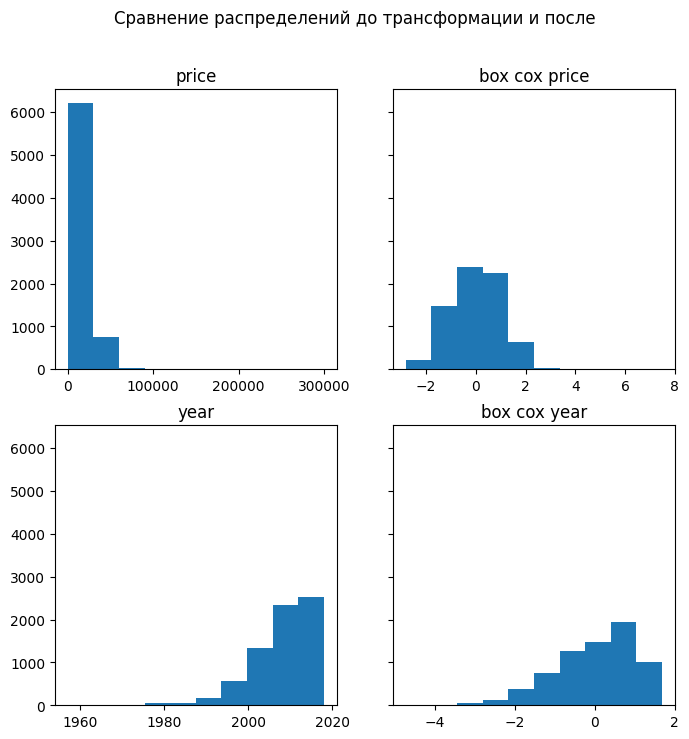

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=True)
axs[0][0].hist(ford_price_data['price'])
axs[1][0].hist(ford_price_data['year'])
axs[0][1].hist(data_box_cox['transformed_price'])
axs[1][1].hist(data_box_cox['transformed_year'])

axs[0][0].set(title='price')
axs[0][1].set(title='box cox price')

axs[1][0].set(title='year')
axs[1][1].set(title='box cox year')

fig.suptitle('Сравнение распределений до трансформации и после')

plt.show()